## Data prep notebook 1
Notebook for preparing the new dataset created by first subsetting bdd100k, and then dividing in 2 parts:

control: 'clear' weather and 'good' visibility

stress: everything remaining was in stress

In [ ]:
from zipfile import ZipFile
from tqdm import tqdm
import os
import json
import shutil

# Dataset

## BDD100k

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# bdd-100k dataset path
zip_path="/content/drive/MyDrive/Seminar-XAI-Project/bdd100k_images_100k.zip"
zip_output_path="/content/drive/MyDrive/Seminar-XAI-Project/bdd100k_images_100k"

In [ ]:
!mkdir $zip_output_path

mkdir: cannot create directory ‘/content/drive/MyDrive/Seminar-XAI-Project/bdd100k_images_100k’: File exists


In [ ]:

with ZipFile(zip_path, 'r') as zip_ref:
    for file_info in tqdm(zip_ref.infolist(), desc="Extracting files"):
        target_path = os.path.join(zip_output_path, file_info.filename)

        # Skip if the file already exists
        if os.path.exists(target_path):
            continue

        # Make sure parent directories exist
        os.makedirs(os.path.dirname(target_path), exist_ok=True)

        # Extract the file
        zip_ref.extract(file_info, zip_output_path)

Extracting files:   0%|          | 2/100004 [00:19<1:38:29, 16.92it/s]

In [ ]:
# check if file exists
!ls -l $zip_output_path

ls: cannot access '/content/drive/MyDrive/Seminar-XAI-Project/bdd100k_images_100k': No such file or directory


## RWVC-BDD100K

In [ ]:

r_zip_path="/content/drive/MyDrive/Seminar-XAI-Project/RWVC-BDD100K-main.zip"
r_zip_output_path="/content/drive/MyDrive/Seminar-XAI-Project/RWVC-BDD100K-main"

In [ ]:
!mkdir $r_zip_output_path

mkdir: cannot create directory ‘/content/drive/MyDrive/Seminar-XAI-Project/RWVC-BDD100K-main’: File exists


In [ ]:

with ZipFile(r_zip_path, 'r') as zip_ref:
    for file_info in tqdm(zip_ref.infolist(), desc="Extracting files"):
        target_path = os.path.join(r_zip_output_path, file_info.filename)

        # Skip if the file already exists
        if os.path.exists(target_path):
            continue

        # Make sure parent directories exist
        os.makedirs(os.path.dirname(target_path), exist_ok=True)

        # Extract the file
        zip_ref.extract(file_info, r_zip_output_path)

Extracting files: 100%|██████████| 11/11 [00:00<00:00, 30.55it/s]


In [ ]:
# labels_path
zip_path="/content/drive/MyDrive/Seminar-XAI-Project/bdd100k_labels.zip"
zip_output_path="/content/drive/MyDrive/Seminar-XAI-Project/bdd100k_labels"



In [ ]:


# Paths
drive_zip_path = "/content/drive/MyDrive/Seminar-XAI-Project/bdd100k_labels.zip"
local_zip_path = "/content/bdd100k_labels.zip"
local_extract_path = "/content/bdd100k_labels"

# Step 1: Copy zip from Drive → local runtime
if not os.path.exists(local_zip_path):
    print("Copying zip file to local runtime...")
    shutil.copy(drive_zip_path, local_zip_path)
    print("Copy complete.")
else:
    print("Zip already exists in local runtime. Skipping copy.")

# Step 2: Extract locally
if not os.path.exists(local_extract_path):
    print("Extracting locally...")
    with ZipFile(local_zip_path, 'r') as zip_ref:
        for file_info in tqdm(zip_ref.infolist(), desc="Extracting files"):
            zip_ref.extract(file_info, local_extract_path)
    print("Extraction complete.")
else:
    print("Already extracted locally. Skipping extraction.")

Copying zip file to local runtime...
Copy complete.
Extracting locally...


Extracting files: 100%|██████████| 100004/100004 [00:30<00:00, 3231.42it/s]

Extraction complete.


In [ ]:
!mkdir $zip_output_path

mkdir: cannot create directory ‘/content/drive/MyDrive/Seminar-XAI-Project/bdd100k_labels’: File exists


In [ ]:

with ZipFile(zip_path, 'r') as zip_ref:
    for file_info in tqdm(zip_ref.infolist(), desc="Extracting files"):
        target_path = os.path.join(zip_output_path, file_info.filename)

        # Skip if the file already exists
        if os.path.exists(target_path):
            continue

        # Make sure parent directories exist
        os.makedirs(os.path.dirname(target_path), exist_ok=True)

        # Extract the file
        zip_ref.extract(file_info, zip_output_path)

Extracting files:   8%|▊         | 7821/100004 [00:59<11:38, 131.92it/s] 


KeyboardInterrupt: 

## new dataset

In [ ]:
# folder_path="/content/drive/MyDrive/Seminar-XAI-Project/new_dataset"
# images_folder=folder_path+"/images"
# labels_folder=folder_path+"/labels"

In [ ]:
# !mkdir $zip_output_path folder_path
# !mkdir $zip_output_path images_folder
# !mkdir $zip_output_path labels_folder

In [ ]:

base_path = "/content/drive/MyDrive/Seminar-XAI-Project"
rwvc_path = base_path + "/RWVC-BDD100K-main/RWVC-BDD100K-main"

# Source paths
image_base = os.path.join(base_path, "bdd100k_images_100k/100k")
label_base = os.path.join("/content", "bdd100k_labels/100k")

# JSON files
json_files = {
    "train": os.path.join(rwvc_path, "train_labels.json"),
    "val": os.path.join(rwvc_path, "valid_labels.json"),
    "test": os.path.join(rwvc_path, "test_labels.json"),
}

# Destination
output_base = os.path.join("/content", "new_dataset")

def get_label_path(img_rel_path):
    return img_rel_path.replace(".jpg", ".json")


# 🔴 Tracking containers
missing_images = []
missing_labels = []
both_missing = []

total_processed = 0
total_copied = 0



In [ ]:
from tqdm import tqdm

for split, json_path in json_files.items():
    print(f"\nProcessing {split}...")
    if split == "train":
      print(f"Skipping {split} split to avoid affecting original train data.")
      continue

    with open(json_path, "r") as f:
        data = json.load(f)

    for item in tqdm(data, desc=f"{split}", leave=True):
        total_processed += 1

        img_rel = item["img"]
        img_rel = img_rel.replace("/0.jpg", ".jpg")

        visibility = item.get("visibility")
        weather = item.get("weather")

        category = "control" if (visibility == "good" and weather == "clear") else "stress"

        img_src = os.path.join(image_base, "train", img_rel)
        label_src = os.path.join(label_base, "train", get_label_path(img_rel))

        img_dst = os.path.join(output_base, category, "images", split, img_rel)
        label_dst = os.path.join(output_base, category, "labels", split, get_label_path(img_rel))

        img_exists = os.path.exists(img_src)
        label_exists = os.path.exists(label_src)

        if not img_exists and not label_exists:
            both_missing.append((split, img_rel))
            continue
        elif not img_exists:
            missing_images.append((split, img_rel))
            continue
        elif not label_exists:
            missing_labels.append((split, img_rel))
            continue

        os.makedirs(os.path.dirname(img_dst), exist_ok=True)
        os.makedirs(os.path.dirname(label_dst), exist_ok=True)

        shutil.copy2(img_src, img_dst)
        shutil.copy2(label_src, label_dst)

        total_copied += 1





Processing train...
Skipping train split to avoid affecting original train data.

Processing val...


val: 100%|██████████| 2500/2500 [09:21<00:00,  4.45it/s]



Processing test...


test: 100%|██████████| 2000/2000 [07:24<00:00,  4.50it/s]


In [ ]:
import os

base = "/content/new_dataset"
categories = ["control", "stress"]
splits = ["train", "val", "test"]

counts = {}

for category in categories:
    counts[category] = {}
    for split in splits:
        path = os.path.join(base, category, "images", split)

        if os.path.exists(path):
            num_files = len([
                f for f in os.listdir(path)
                if f.endswith(".jpg")
            ])
        else:
            num_files = 0

        counts[category][split] = num_files

# ✅ Print nicely
print("\n===== DATASET DISTRIBUTION =====")
total_all = 0

for category in categories:
    print(f"\n{category.upper()}:")
    total_cat = 0

    for split in splits:
        count = counts[category][split]
        print(f"  {split}: {count}")
        total_cat += count

    print(f"  Total ({category}): {total_cat}")
    total_all += total_cat

print(f"\nTOTAL DATASET SIZE: {total_all}")


===== DATASET DISTRIBUTION =====

CONTROL:
  train: 1973
  val: 561
  test: 448
  Total (control): 2982

STRESS:
  train: 6827
  val: 1939
  test: 1552
  Total (stress): 10318

TOTAL DATASET SIZE: 13300


In [ ]:
import random
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

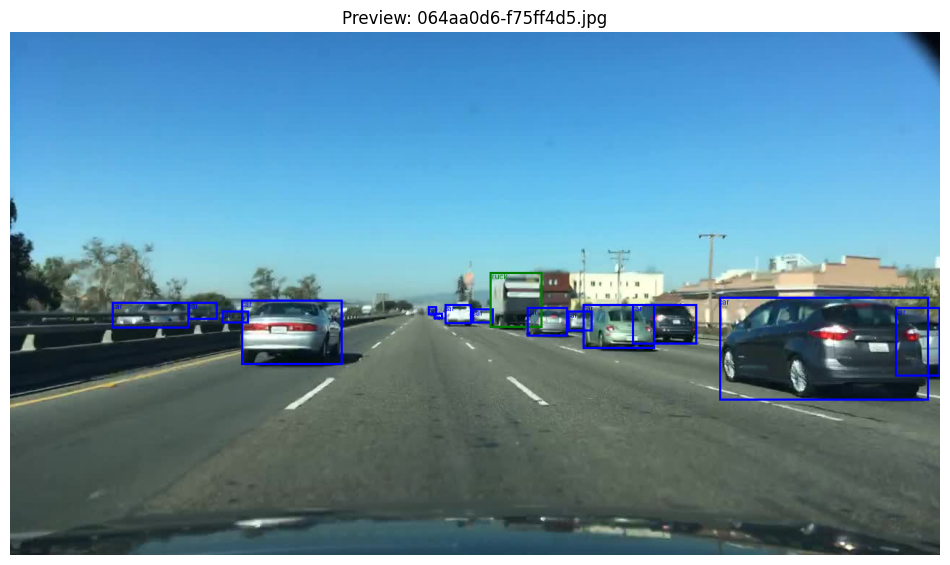

In [ ]:


# Update these paths to your control folder
control_base = "/content/new_dataset/control"
images_dir = os.path.join(control_base, "images/train")   # or val/test
labels_dir = os.path.join(control_base, "labels/train")

CLASSES = ["pedestrian", "car", "truck"]
COLOR_MAP = {"pedestrian": "red", "car": "blue", "truck": "green"}

def preview_random_control_image():
    # Pick a random image file
    img_files = os.listdir(images_dir)
    img_file = random.choice(img_files)

    img_path = os.path.join(images_dir, img_file)
    label_path = os.path.join(labels_dir, img_file.replace(".jpg", ".json"))

    # Load image
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    # Load labels
    with open(label_path, "r") as f:
        data = json.load(f)

    frame = data["frames"][0]
    for obj in frame["objects"]:
        cat = obj["category"]
        if cat in CLASSES:
            x1 = obj["box2d"]["x1"]
            y1 = obj["box2d"]["y1"]
            x2 = obj["box2d"]["x2"]
            y2 = obj["box2d"]["y2"]
            draw.rectangle([x1, y1, x2, y2], outline=COLOR_MAP[cat], width=3)
            draw.text((x1, y1), cat, fill=COLOR_MAP[cat])

    # Show image
    plt.figure(figsize=(12,8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Preview: {img_file}")
    plt.show()

# Example usage
preview_random_control_image()

In [ ]:

# Local folder you want to zip
local_folder = "/content/new_dataset"  # replace with your folder path

# Destination zip path in Drive
drive_zip_path = "/content/drive/MyDrive/Seminar-XAI-Project/new_dataset.zip"

# Make sure parent directories exist in Drive
os.makedirs(os.path.dirname(drive_zip_path), exist_ok=True)

# Create zip and copy to Drive
shutil.make_archive(base_name=drive_zip_path.replace(".zip", ""),  # remove .zip for base_name
                    format="zip",
                    root_dir=local_folder)

print(f"Folder zipped and copied to Drive: {drive_zip_path}")

KeyboardInterrupt: 

In [ ]:
zip_path = "/content/new_dataset.zip"
shutil.make_archive(base_name=zip_path.replace(".zip", ""),  # remove .zip for base_name
                    format="zip",
                    root_dir=local_folder)

## Visualize